In [1]:
import cv2
import os

img_dir = 'Croptimal/resnet/train/'

class_subdirs = [
    # Class 0
    # (subdir, weight)
    [('sobel_class_0', 1.0)],
    # Class 1
    [('sobel_class_1', 1.0)]]

n_classes = len(class_subdirs)
global_imgs = []

for i, class_data in enumerate(class_subdirs):
    global_imgs.append([])
    for subdir, weight in class_data:
        class_path = os.path.join(img_dir, subdir)
        for img_file in os.listdir(class_path):
            if img_file.endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                img_path = os.path.join(class_path, img_file)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    global_imgs[i].append(img)

for i in range(n_classes):
    print(f'Loaded {len(global_imgs[i])} images for class {i}')

Loaded 2258 images for class 0
Loaded 1390 images for class 1


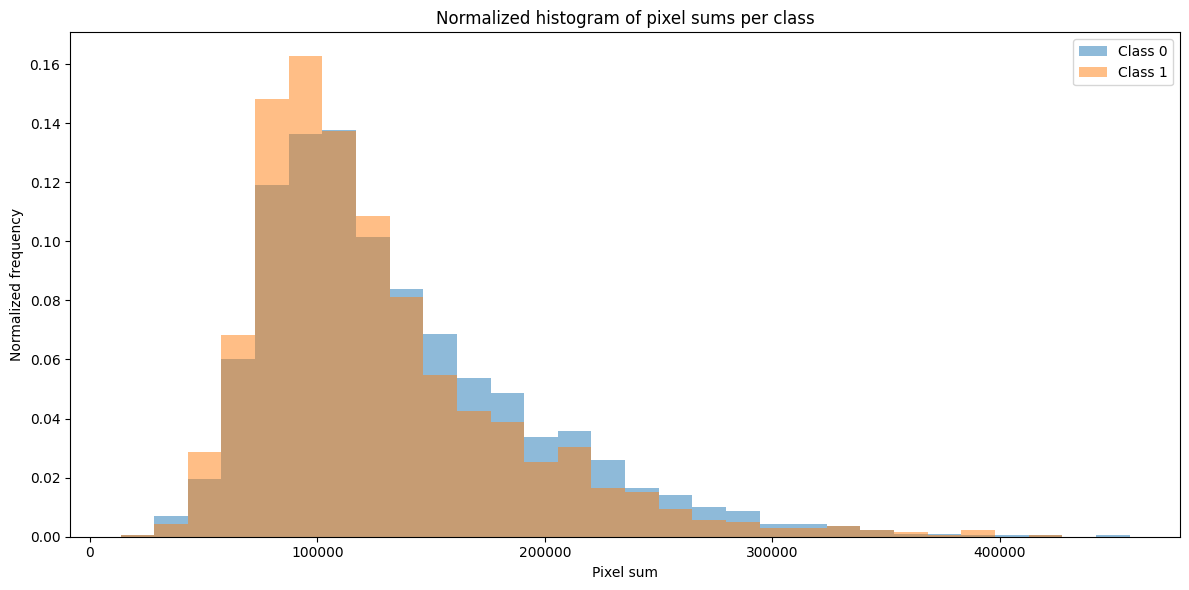

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

all_sums = [np.array([img.sum() for img in imgs]) for imgs in global_imgs]
bins = np.histogram_bin_edges(np.concatenate(all_sums), bins=30)

for idx, pixel_sums in enumerate(all_sums):
    weights = np.ones_like(pixel_sums, dtype=float) / len(pixel_sums)
    plt.hist(
        pixel_sums,
        bins=bins,
        weights=weights,
        alpha=0.5,
        label=f'Class {idx}'
    )

plt.xlabel('Pixel sum')
plt.ylabel('Normalized frequency')
plt.title('Normalized histogram of pixel sums per class')
plt.legend()
plt.tight_layout()
plt.show()
